In [4]:
!pip install rouge

In [ ]:
import collections
import math
import os
import pathlib
import random
import re
import string
import time
import urllib.request

import einops
import matplotlib.pyplot as plt
import numpy as np
import requests
import tqdm

import tensorflow as tf
import tensorflow_text as text
import tensorflow_datasets as tfds
from google.colab.patches import cv2_imshow
import cv2 as cv

import os
import nltk
nltk.download('wordnet')
from nltk.translate import meteor_score
from nltk.translate.bleu_score import corpus_bleu
from rouge import Rouge

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


1115419746/1115419746 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
2340801/2340801 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


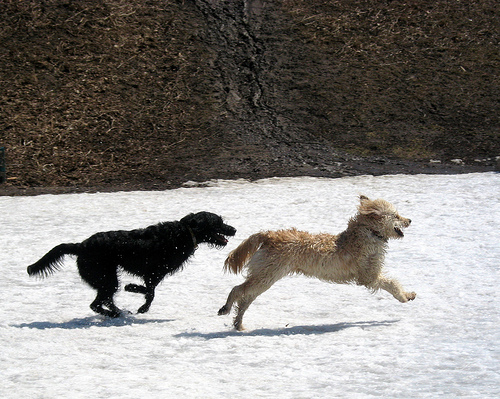

In [ ]:
def flickr8k(path='flickr8k'):
    path = pathlib.Path(path)

    if len(list(path.rglob('*'))) < 16197:
        tf.keras.utils.get_file(
            origin='https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip',
            cache_dir='.',
            cache_subdir=str(path),
            extract=True)
        tf.keras.utils.get_file(
            origin='https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip',
            cache_dir='.',
            cache_subdir=str(path),
            extract=True)

    captions = (path/"Flickr8k_text.zip/Flickr8k.token.txt").read_text().splitlines()
    captions = (line.split('\t') for line in captions if '\t' in line)
    captions = ((fname.split('#')[0], caption) for (fname, caption) in captions)

    cap_dict = collections.defaultdict(list)
    for fname, cap in captions:
        cap_dict[fname].append(cap)

    train_files = (path/'Flickr8k_text.zip/Flickr_8k.trainImages.txt').read_text().splitlines()
    test_files = (path/'Flickr8k_text.zip/Flickr_8k.testImages.txt').read_text().splitlines()
    validation_files = (path/'Flickr8k_text.zip/Flickr_8k.devImages.txt').read_text().splitlines()

    train_captions = [(str(path/'Flickr8k_Dataset.zip/Flicker8k_Dataset'/fname), cap_dict[fname]) for fname in train_files]
    test_captions = [(str(path/'Flickr8k_Dataset.zip/Flicker8k_Dataset'/fname), cap_dict[fname]) for fname in test_files]
    validation_captions = [(str(path/'Flickr8k_Dataset.zip/Flicker8k_Dataset'/fname), cap_dict[fname]) for fname in validation_files]

    # Use a generator to build the datasets
    def gen_dataset(captions_list):
        for img_path, captions in captions_list:
            yield img_path, captions

    output_signature = (
        tf.TensorSpec(shape=(), dtype=tf.string),
        tf.TensorSpec(shape=(None,), dtype=tf.string)
    )

    train_ds = tf.data.Dataset.from_generator(lambda: gen_dataset(train_captions),
                                                output_signature=output_signature)
    test_ds = tf.data.Dataset.from_generator(lambda: gen_dataset(test_captions),
                                               output_signature=output_signature)
    validation_ds = tf.data.Dataset.from_generator(lambda: gen_dataset(validation_captions),
                                                     output_signature=output_signature)

    # Show an example image.
    example_img_path = str(path/'Flickr8k_Dataset.zip/Flicker8k_Dataset'/'2513260012_03d33305cf.jpg')
    img = cv.imread(example_img_path)
    cv2_imshow(img)

    return path, train_ds, test_ds, validation_ds, test_files, cap_dict, example_img_path

path, train_raw, test_raw, validation_raw, test_images, cap_dict, example_img_path = flickr8k()

In [ ]:
IMAGE_SHAPE = (224, 224, 3)

def load_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMAGE_SHAPE[:2])
    return img

for ex_path, ex_caps in train_raw.take(1):
    test_img_batch = load_image(ex_path)[tf.newaxis, :]
    print("Test image batch shape:", test_img_batch.shape)
    print("MobileNet output shape:", mobilenet_output := tf.keras.applications.MobileNetV3Small(
        input_shape=IMAGE_SHAPE, include_top=False, include_preprocessing=True)(test_img_batch).shape)

Test image batch shape: (1, 224, 224, 3)
4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNet output shape: (1, 7, 7, 576)


In [ ]:
def standardize(s):
    s = tf.strings.lower(s)
    s = tf.strings.regex_replace(s, f'[{re.escape(string.punctuation)}]', '')
    s = tf.strings.join(['[START]', s, '[END]'], separator=' ')
    return s

vocabulary_size = 5000
tokenizer = tf.keras.layers.TextVectorization(
    max_tokens=vocabulary_size,
    standardize=standardize,
    ragged=True,
    output_mode="int",
    output_sequence_length=20)
tokenizer.adapt(train_raw.map(lambda fp, caps: caps).unbatch().batch(1024))

word_to_index = tf.keras.layers.StringLookup(
    mask_token="",
    vocabulary=tokenizer.get_vocabulary())
index_to_word = tf.keras.layers.StringLookup(
    mask_token="",
    vocabulary=tokenizer.get_vocabulary(),
    invert=True)

In [ ]:
def match_shapes(images, captions):
    caption_shape = einops.parse_shape(captions, 'b c')
    captions = einops.rearrange(captions, 'b c -> (b c)')
    images = einops.repeat(images, 'b ... -> (b c) ...', c=caption_shape['c'])
    return images, captions

def prepare_txt(imgs, txts):
    tokens = tokenizer(txts)
    input_tokens = tokens[..., :-1]
    label_tokens = tokens[..., 1:]
    return (imgs, input_tokens), label_tokens

def to_tensor(inputs, labels):
    (images, in_tok), out_tok = inputs, labels
    return (images, in_tok.to_tensor(default_value=0)), out_tok.to_tensor(default_value=0)

def augment_image(image):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    return image

def prepare_dataset(ds, batch_size=32, shuffle_buffer=1000, augment=False):
    ds = ds.shuffle(10000)
    ds = ds.map(lambda path, caption: (load_image(path), caption),
                num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(lambda image, caption: (augment_image(image), caption),
                    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.map(match_shapes, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.unbatch()
    ds = ds.shuffle(shuffle_buffer)
    ds = ds.batch(batch_size)
    ds = ds.map(prepare_txt, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(to_tensor, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = prepare_dataset(train_raw, augment=True)
test_ds = prepare_dataset(test_raw, augment=False)
validation_ds = prepare_dataset(validation_raw, augment=False)

In [ ]:
mobilenet = tf.keras.applications.MobileNetV3Small(
    input_shape=IMAGE_SHAPE,
    include_top=False,
    include_preprocessing=True)
mobilenet.trainable = False
mobilenet.summary()

Model: "MobileNetV3Small"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_1 (Rescaling)   │ (None, 224, 224, 3)    │              0 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv (Conv2D)             │ (None, 112, 112, 16)   │            432 │ rescaling_1[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv_bn                   │ (None, 112, 112, 16)   │             64 │ conv[0][0]             │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_18             │ (None, 112, 112, 16)   │              0 │ conv_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 113, 113, 16)   │              0 │ activation_18[0][0]    │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 56, 56, 16)     │            144 │ expanded_conv_depthwi… │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 56, 56, 16)     │             64 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_14 (ReLU)           │ (None, 56, 56, 16)     │              0 │ expanded_conv_depthwi… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_squeeze_ex… │ (None, 1, 1, 16)       │              0 │ re_lu_14[0][0]         │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_squeeze_ex… │ (None, 1, 1, 8)        │            136 │ expanded_conv_squeeze… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_squeeze_ex… │ (None, 1, 1, 8)        │              0 │ expanded_conv_squeeze… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_squeeze_ex… │ (None, 1, 1, 16)       │            144 │ expanded_conv_squeeze… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_9 (Add)               │ (None, 1, 1, 16)       │              0 │ expanded_conv_squeeze… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_15 (ReLU)      

 Total params: 939,120 (3.58 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 939,120 (3.58 MB)

In [ ]:
class SeqEmbedding(tf.keras.layers.Layer):
    def __init__(self, vocab_size, max_length, depth):
        super().__init__()
        self.pos_embedding = tf.keras.layers.Embedding(input_dim=max_length, output_dim=depth)
        self.token_embedding = tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=depth,
            mask_zero=True
        )
        self.add = tf.keras.layers.Add()

    def call(self, seq):
        token_embed = self.token_embedding(seq)
        seq_length = tf.shape(token_embed)[1]
        positions = tf.range(start=0, limit=seq_length, delta=1)
        pos_embed = self.pos_embedding(positions)
        pos_embed = tf.expand_dims(pos_embed, axis=0)
        return self.add([token_embed, pos_embed])

class CausalSelfAttention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__()
        self.mha = tf.keras.layers.MultiHeadAttention(**kwargs)
        self.add = tf.keras.layers.Add()
        self.layernorm = tf.keras.layers.LayerNormalization()

    def call(self, x):
        attn = self.mha(query=x, value=x, use_causal_mask=True)
        x = self.add([x, attn])
        return self.layernorm(x)

class CrossAttention(tf.keras.layers.Layer):
    def __init__(self, key_dim=256, num_heads=8, **kwargs):
        super().__init__()
        self.mha = tf.keras.layers.MultiHeadAttention(key_dim=key_dim, num_heads=num_heads, **kwargs)
        self.add = tf.keras.layers.Add()
        self.layernorm = tf.keras.layers.LayerNormalization()

    def call(self, x, y, **kwargs):
        if x.shape[-1] != y.shape[-1]:
            y = tf.keras.layers.Dense(x.shape[-1])(y)
        attn, attention_scores = self.mha(query=x, value=y, return_attention_scores=True)
        self.last_attention_scores = attention_scores
        x = self.add([x, attn])
        return self.layernorm(x)

class FeedForward(tf.keras.layers.Layer):
    def __init__(self, units, dropout_rate=0.1):
        super().__init__()
        self.seq = tf.keras.Sequential([
            tf.keras.layers.Dense(units=2*units, activation='relu'),
            tf.keras.layers.Dense(units=units),
            tf.keras.layers.Dropout(rate=dropout_rate)
        ])
        self.layernorm = tf.keras.layers.LayerNormalization()

    def call(self, x):
        x = x + self.seq(x)
        return self.layernorm(x)

class DecoderLayer(tf.keras.layers.Layer):
    def __init__(self, units, num_heads=1, dropout_rate=0.1):
        super().__init__()
        self.self_attention = CausalSelfAttention(num_heads=num_heads, key_dim=units, dropout=dropout_rate)
        self.cross_attention = CrossAttention(num_heads=num_heads, key_dim=units, dropout=dropout_rate)
        self.ff = FeedForward(units=units, dropout_rate=dropout_rate)

    def call(self, inputs, training=False):
        in_seq, out_seq = inputs
        out_seq = self.self_attention(out_seq)
        out_seq = self.cross_attention(out_seq, in_seq)
        self.last_attention_scores = self.cross_attention.last_attention_scores
        out_seq = self.ff(out_seq)
        return out_seq

class TokenOutput(tf.keras.layers.Layer):
    def __init__(self, tokenizer, banned_tokens=('', '[UNK]', '[START]'), **kwargs):
        super().__init__()
        self.dense = tf.keras.layers.Dense(units=tokenizer.vocabulary_size(), **kwargs)
        self.tokenizer = tokenizer
        self.banned_tokens = banned_tokens
        self.bias = None

    def adapt(self, ds):
        counts = collections.Counter()
        vocab = self.tokenizer.get_vocabulary()
        vocab_dict = {token: idx for idx, token in enumerate(vocab)}
        for tokens in tqdm.tqdm(ds):
            counts.update(tokens.numpy().flatten())
        counts_arr = np.zeros((self.tokenizer.vocabulary_size(),))
        for token, count in counts.items():
            if token < self.tokenizer.vocabulary_size():
                counts_arr[token] = count
        for token in self.banned_tokens:
            counts_arr[vocab_dict[token]] = 0
        total = counts_arr.sum()
        p = counts_arr / total
        p[counts_arr == 0] = 1.0
        log_p = np.log(p)
        entropy = -(log_p * p).sum()
        print(f"Uniform entropy: {np.log(self.tokenizer.vocabulary_size()):0.2f}")
        print(f"Marginal entropy: {entropy:0.2f}")
        self.bias = log_p
        self.bias[counts_arr == 0] = -1e9

    def call(self, x):
        x = self.dense(x)
        return x + self.bias

output_layer = TokenOutput(tokenizer, banned_tokens=('', '[UNK]', '[START]'))
output_layer.adapt(train_ds.map(lambda inputs, labels: labels))

938it [00:45, 20.56it/s]


Uniform entropy: 8.52
Marginal entropy: 5.30


In [ ]:
class Captioner(tf.keras.Model):
    @classmethod
    def add_method(cls, fun):
        setattr(cls, fun.__name__, fun)
        return fun

    def __init__(self, tokenizer, feature_extractor, output_layer, num_layers=1,
                 units=256, max_length=50, num_heads=1, dropout_rate=0.1):
        super().__init__()
        self.feature_extractor = feature_extractor
        self.tokenizer = tokenizer
        self.word_to_index = tf.keras.layers.StringLookup(
            mask_token="",
            vocabulary=tokenizer.get_vocabulary())
        self.index_to_word = tf.keras.layers.StringLookup(
            mask_token="",
            vocabulary=tokenizer.get_vocabulary(),
            invert=True)
        self.seq_embedding = SeqEmbedding(
            vocab_size=tokenizer.vocabulary_size(),
            depth=units,
            max_length=max_length)
        self.image_dense = tf.keras.layers.Dense(units)
        self.decoder_layers = [
            DecoderLayer(units, num_heads=num_heads, dropout_rate=dropout_rate)
            for _ in range(num_layers)
        ]
        self.output_layer = output_layer

@Captioner.add_method
def call(self, inputs):
    image, txt = inputs
    if image.shape[-1] == 3:
        image = self.feature_extractor(image)
        image = self.image_dense(image)
    image = einops.rearrange(image, 'b h w c -> b (h w) c')
    if txt.dtype == tf.string:
        txt = self.tokenizer(txt)
    txt = self.seq_embedding(txt)
    for dec_layer in self.decoder_layers:
        txt = dec_layer((image, txt))
    txt = self.output_layer(txt)
    return txt

@Captioner.add_method
def simple_gen(self, image, temperature=1):
    if len(image.shape) == 3:
        image = image[tf.newaxis, ...]
    initial = self.word_to_index([['[START]']])
    tokens = initial
    end_token = int(self.word_to_index(['[END]'])[0])

    img_features = self.feature_extractor(image)

    for _ in range(50):
        preds = self((img_features, tokens))
        preds = preds[:, -1, :]

        if temperature == 0:
            next_token = tf.argmax(preds, axis=-1, output_type=tf.int64)[:, tf.newaxis]
        else:
            next_token = tf.random.categorical(preds / temperature, num_samples=1)
            next_token = tf.cast(next_token, tf.int64)

        next_token = tf.reshape(next_token, [tf.shape(tokens)[0], -1])

        tokens = tf.concat([tokens, next_token], axis=1)

        if int(next_token[0, 0]) == end_token:
            break

    words = self.index_to_word(tokens[0, 1:-1])
    result = tf.strings.reduce_join(words, separator=' ')
    return result.numpy().decode()

@Captioner.add_method
def run_and_show_attention(self, image, temperature=0.0):
    result_txt = self.simple_gen(image, temperature)
    str_tokens = result_txt.split()
    str_tokens.append('[END]')
    attn_maps = [layer.last_attention_scores for layer in self.decoder_layers
                 if hasattr(layer, 'last_attention_scores')]
    if not attn_maps:
        print("No attention maps available.")
        return result_txt
    attn_maps = tf.concat(attn_maps, axis=0)
    attention_maps = einops.reduce(attn_maps,
                                   'batch heads sequence (h w) -> sequence h w',
                                   h=7, w=7, reduction='mean')
    plot_attention_maps(image / 255, str_tokens, attention_maps)
    plt.suptitle(result_txt, y=1.05)
    print("Generated Caption:", result_txt)
    return result_txt

def plot_attention_maps(image, str_tokens, attention_map):
    num_tokens = len(str_tokens)
    grid_cols = max(int(np.ceil(num_tokens / 3)), 2)
    fig = plt.figure(figsize=(16, 9))
    for i in range(num_tokens):
        ax = fig.add_subplot(3, grid_cols, i + 1)
        ax.set_title(str_tokens[i])
        ax.imshow(image)
        ax.imshow(attention_map[i], cmap='gray', alpha=0.6)
    plt.tight_layout()
    plt.show()

model = Captioner(tokenizer,
                  feature_extractor=mobilenet,
                  output_layer=output_layer,
                  units=256,
                  dropout_rate=0.5,
                  max_length=150,
                  num_layers=2,
                  num_heads=2)

test_image = load_image(example_img_path)
print("Simple generation (temperature=0.0):")
print(model.simple_gen(test_image, temperature=0.0))

Simple generation (temperature=0.0):


/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:907: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 2, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'captioner', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a a


In [ ]:
def kl_divergence_loss(labels, preds):
    preds_prob = tf.nn.softmax(preds, axis=-1)

    vocab_size = tf.shape(preds)[-1]

    labels = tf.cast(labels, tf.int32)

    labels_onehot = tf.one_hot(labels, depth=vocab_size, dtype=tf.float32)

    mask = tf.cast(tf.not_equal(labels, 0), dtype=tf.float32)

    kl_fn = tf.keras.losses.KLDivergence(reduction=tf.keras.losses.Reduction.NONE)

    loss = kl_fn(labels_onehot, preds_prob)

    loss = loss * mask

    loss = tf.reduce_sum(loss) / tf.reduce_sum(mask)
    return loss

def masked_acc(labels, preds):
    mask = tf.cast(tf.not_equal(labels, 0), tf.float32)
    preds = tf.argmax(preds, axis=-1)
    labels = tf.cast(labels, tf.int64)
    match = tf.cast(tf.equal(preds, labels), mask.dtype)
    return tf.reduce_sum(match * mask) / tf.reduce_sum(mask)

class GenerateText(tf.keras.callbacks.Callback):
    def __init__(self, caption_model):
        super().__init__()
        self.caption_model = caption_model
        self.image = load_image(example_img_path)

    def on_epoch_end(self, epoch, logs=None):
        print("\nGenerated Captions at Epoch End:")
        for t in (0.0, 0.5, 1.0):
            caption = self.caption_model.simple_gen(self.image, temperature=t)
            print(f"Temperature {t}: {caption}")

In [ ]:
callbacks = [
    GenerateText(model),
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
]

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss=kl_divergence_loss,
              metrics=[masked_acc])

history = model.fit(
    train_ds.repeat(),
    steps_per_epoch=188,
    validation_data=validation_ds.repeat(),
    validation_steps=32,
    epochs=100,
    callbacks=callbacks
)

Epoch 1/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 4.9966 - masked_acc: 0.2060
Generated Captions at Epoch End:
Temperature 0.0: a man in a white and a man in a red
Temperature 0.5: a man in a man a white and the red and a
Temperature 1.0: a reads competition held camera
188/188 ━━━━━━━━━━━━━━━━━━━━ 50s 138ms/step - loss: 4.9953 - masked_acc: 0.2063 - val_loss: 4.4830 - val_masked_acc: 0.2868
Epoch 2/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 4.3180 - masked_acc: 0.2954
Generated Captions at Epoch End:
Temperature 0.0: a man in a black and white dog is standing in the grass
Temperature 0.5: a man in a black shirt is running in the snow
Temperature 1.0: a man in the dog while pine window and a tennis into standing
188/188 ━━━━━━━━━━━━━━━━━━━━ 22s 116ms/step - loss: 4.3175 - masked_acc: 0.2955 - val_loss: 4.1614 - val_masked_acc: 0.3148
Epoch 3/100
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 4.0669 - masked_acc: 0.3239
Generated Captions at Epoch End:
Temperat

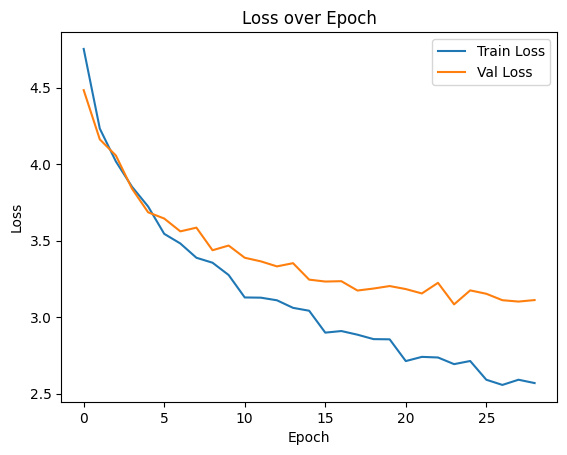

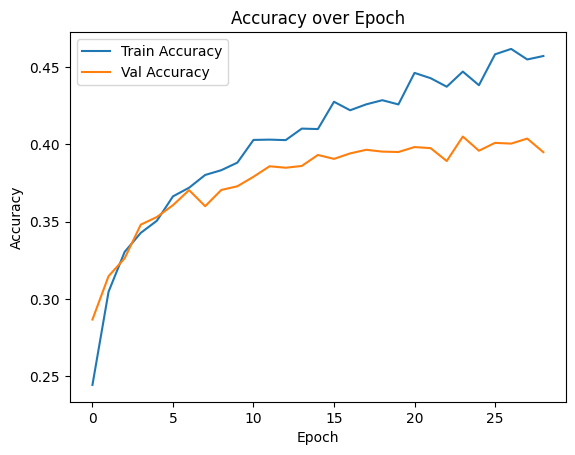

In [ ]:
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title("Loss over Epoch")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['masked_acc'], label='Train Accuracy')
plt.plot(history.history['val_masked_acc'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title("Accuracy over Epoch")
plt.legend()
plt.show()

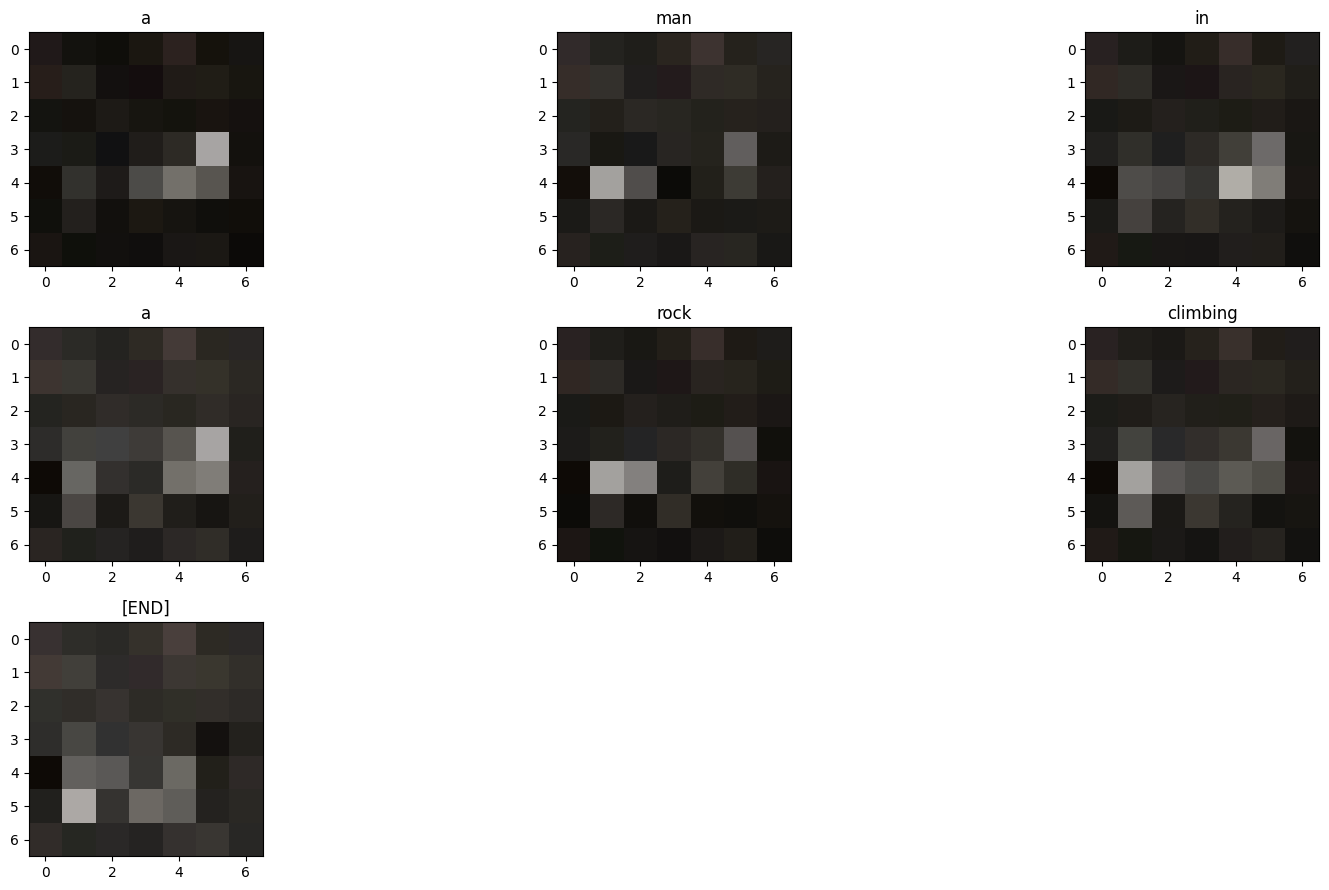

Generated Caption: a man in a rock climbing
Example image filename: 2513260012_03d33305cf.jpg
Reference Captions: ['A black dog is running after a white dog in the snow .', 'Black dog chasing brown dog through snow', 'Two dogs chase each other across the snowy ground .', 'Two dogs play together in the snow .', 'Two dogs running through a low lying body of water .']
METEOR Scores: [0.12195121951219513, 0.0, 0.0, 0.06410256410256411, 0.04761904761904762]


<Figure size 640x480 with 0 Axes>

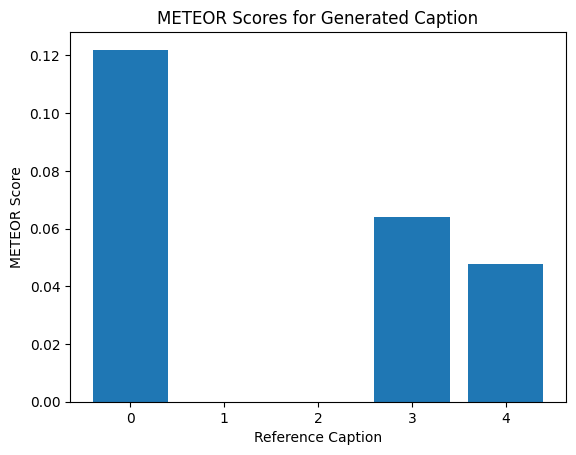

BLEU-1 Score: 0.28216057496353797
BLEU-2 Score: 7.2900276358863456e-155
BLEU-3 Score: 5.2410088978830294e-204
BLEU-4 Score: 1.171778691554733e-231
ROUGE-1 Scores: {'r': 0.06666666666666667, 'p': 0.4, 'f': 0.11428571183673475}


/usr/local/lib/python3.11/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.11/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.11/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_

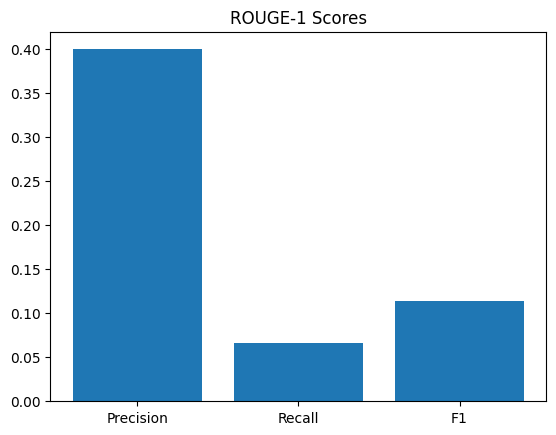

In [ ]:
result_txt = model.run_and_show_attention(test_image, temperature=0.0)

fileName = os.path.basename(example_img_path)
print("Example image filename:", fileName)
reference_captions = cap_dict[fileName]
print("Reference Captions:", reference_captions)

result_words = result_txt.split()
meteor_scores = [meteor_score.single_meteor_score(ref.split(), result_words) for ref in reference_captions]
print("METEOR Scores:", meteor_scores)
max_meteor = max(meteor_scores)
plt.figure()
plt.bar(range(len(meteor_scores)), meteor_scores, align='center')
plt.xlabel('Reference Caption')
plt.ylabel('METEOR Score')
plt.title('METEOR Scores for Generated Caption')
plt.show()

reference_tokenized = [ref.split() for ref in reference_captions]
result_tokenized = result_txt.split()
bleu_1 = corpus_bleu([reference_tokenized], [result_tokenized], weights=(1, 0, 0, 0))
bleu_2 = corpus_bleu([reference_tokenized], [result_tokenized], weights=(0.5, 0.5, 0, 0))
bleu_3 = corpus_bleu([reference_tokenized], [result_tokenized], weights=(0.33, 0.33, 0.33, 0))
bleu_4 = corpus_bleu([reference_tokenized], [result_tokenized], weights=(0.25, 0.25, 0.25, 0.25))
print(f'BLEU-1 Score: {bleu_1}')
print(f'BLEU-2 Score: {bleu_2}')
print(f'BLEU-3 Score: {bleu_3}')
print(f'BLEU-4 Score: {bleu_4}')

rouge = Rouge(metrics=["rouge-1"])
rouge_scores = rouge.get_scores(result_txt, " ".join(reference_captions), avg=True)
print("ROUGE-1 Scores:", rouge_scores['rouge-1'])
plt.figure()
plt.bar(['Precision', 'Recall', 'F1'], [rouge_scores['rouge-1']['p'],
                                          rouge_scores['rouge-1']['r'],
                                          rouge_scores['rouge-1']['f']])
plt.title('ROUGE-1 Scores')
plt.show()

def evaluate_captions(reference_captions, generated_caption):
    if not generated_caption.strip():
        print("Warning: Generated caption is empty; setting METEOR score to 0.")
        meteor_scores = [0.0 for _ in reference_captions]
    else:
        meteor_scores = [meteor_score.single_meteor_score(ref.split(), generated_caption.split())
                         for ref in reference_captions]
    max_meteor = max(meteor_scores) if meteor_scores else 0.0
    print(f"METEOR Scores: {meteor_scores}")
    print(f"Max METEOR Score: {max_meteor}")

    reference_tokenized = [ref.split() for ref in reference_captions]
    generated_tokenized = generated_caption.split()
    bleu_1 = corpus_bleu([reference_tokenized], [generated_tokenized], weights=(1, 0, 0, 0))
    bleu_2 = corpus_bleu([reference_tokenized], [generated_tokenized], weights=(0.5, 0.5, 0, 0))
    bleu_3 = corpus_bleu([reference_tokenized], [generated_tokenized], weights=(0.33, 0.33, 0.33, 0))
    bleu_4 = corpus_bleu([reference_tokenized], [generated_tokenized], weights=(0.25, 0.25, 0.25, 0.25))
    print(f'BLEU-1 Score: {bleu_1}')
    print(f'BLEU-2 Score: {bleu_2}')
    print(f'BLEU-3 Score: {bleu_3}')
    print(f'BLEU-4 Score: {bleu_4}')

    if not generated_caption.strip():
        print("Warning: Generated caption is empty; setting ROUGE-1 F1 score to 0.")
        rouge_f1 = 0.0
    else:
        rouge = Rouge(metrics=["rouge-1"])
        references_combined = " ".join(reference_captions)
        rouge_scores = rouge.get_scores(generated_caption, references_combined, avg=True)
        rouge_f1 = rouge_scores['rouge-1']['f']
        print("ROUGE-1 F1 Score:", rouge_f1)

    return max_meteor, bleu_1, bleu_2, bleu_3, bleu_4, rouge_f1

In [ ]:
counter = 0
total_meteor = 0
total_bleu_1 = 0
total_bleu_2 = 0
total_bleu_3 = 0
total_bleu_4 = 0
total_rouge_f1 = 0

base_path = pathlib.Path(path)
for image_name in test_images:
    img_path = base_path / 'Flickr8k_Dataset.zip/Flicker8k_Dataset' / image_name
    image = load_image(str(img_path))
    generated_caption = model.simple_gen(image, temperature=0.0)
    print("\n=== Evaluating image:", image_name, "===")
    print("Generated Caption:", generated_caption)
    reference_caps = cap_dict[image_name]
    model.run_and_show_attention(image, temperature=0.0)
    met, b1, b2, b3, b4, r_f1 = evaluate_captions(reference_caps, generated_caption)
    total_meteor += met
    total_bleu_1 += b1
    total_bleu_2 += b2
    total_bleu_3 += b3
    total_bleu_4 += b4
    total_rouge_f1 += r_f1
    counter += 1


--- Average Evaluation Metrics over Test Set ---
Average METEOR Score: 0.22311579472542067
Average BLEU-1 Score: 0.35204616141837325
Average BLEU-2 Score: 0.15171199895778284
Average BLEU-3 Score: 0.030815132217192207
Average BLEU-4 Score: 0.007386776740795815
Average ROUGE-1 F1 Score: 0.20857687205378475


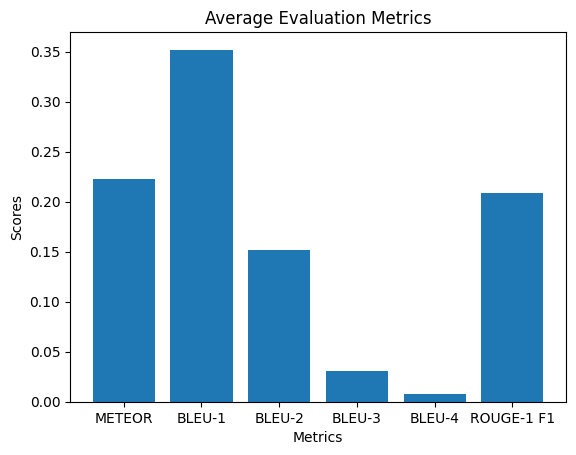

In [18]:
if counter > 0:
    avg_meteor = total_meteor / counter
    avg_bleu_1 = total_bleu_1 / counter
    avg_bleu_2 = total_bleu_2 / counter
    avg_bleu_3 = total_bleu_3 / counter
    avg_bleu_4 = total_bleu_4 / counter
    avg_rouge_f1 = total_rouge_f1 / counter

    print("\n--- Average Evaluation Metrics over Test Set ---")
    print("Average METEOR Score:", avg_meteor)
    print("Average BLEU-1 Score:", avg_bleu_1)
    print("Average BLEU-2 Score:", avg_bleu_2)
    print("Average BLEU-3 Score:", avg_bleu_3)
    print("Average BLEU-4 Score:", avg_bleu_4)
    print("Average ROUGE-1 F1 Score:", avg_rouge_f1)

    metrics_names = ['METEOR', 'BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4', 'ROUGE-1 F1']
    avg_scores = [avg_meteor, avg_bleu_1, avg_bleu_2, avg_bleu_3, avg_bleu_4, avg_rouge_f1]
    plt.figure()
    plt.bar(metrics_names, avg_scores)
    plt.xlabel('Metrics')
    plt.ylabel('Scores')
    plt.title('Average Evaluation Metrics')
    plt.show()